# 1 de cada 3 visitas a una flor en Nepal la hace la misma especie

En 10 aldeas del distrito de Jumla, en el Himalaya nepalí, un equipo registró **10.974 visitas de insectos a flores**. Las flores fueron de 51 cultivos distintos. Los visitantes, 15 taxa de polinizadores. Pero la mayor parte de las visitas — el 76,5% — la hacen solo tres grupos. Y entre esos tres, hay uno que sobresale: *Apis cerana*, la abeja de la miel asiática.

Eso es lo que vamos a reconstruir aquí, con los datos abiertos del paper de Timberlake et al. (Nature, 2026). El estudio dice además que los polinizadores son responsables del **44% del ingreso agrícola** y de **más del 20% del consumo de vitamina A, folato y vitamina E** de estas familias. Esos dos números no los reproducimos en este notebook — requieren cruzar las visitas con datos dietéticos individuales que viven en Git LFS (776 MB), así que los citamos al paper. Lo que sí podemos mostrar — y eso es lo interesante — es la estructura ecológica que los sostiene: quién visita qué, con qué intensidad, y qué pasa con los rendimientos si esa estructura se rompe.

**Paper**: [Pollinators support the nutrition and income of vulnerable communities](https://doi.org/10.1038/s41586-026-10421-x) — Nature, 2026
**DOI**: `10.1038/s41586-026-10421-x`
**Datos**: [Zenodo 18838606](https://zenodo.org/records/18838606) (CC-BY-4.0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-polinizadores-nutricion-nepal/notebook.ipynb)

## Lo que midieron

El equipo trabajó en **10 aldeas** del Patarasi Rural Municipality, distrito de Jumla, en el Nepal himalayo — pequeños productores con economía mixta, parcelas diversificadas. Durante el ciclo de floración, observaron qué insectos visitan qué flores y registraron **10.974 visitas en total**, en **51 especies cultivadas** y unas pocas plantas silvestres asociadas.

A esos datos de visitas les sumaron, para 29 de esos cultivos, la **dependencia de polinización** — qué proporción del rendimiento depende directamente de que un insecto traslade el polen. Con esos dos ingredientes, modelaron qué pasaría con la cosecha si los polinizadores desaparecieran del todo, y qué pasaría con un declive más realista (escenario IPBES). Lo que viene es eso, capa por capa.

In [1]:
# ════════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ════════════════════════════════════════════════════════════════
COLOR_DESTACADO = '#2563EB'   # Azul CaM — barras protagonistas
COLOR_SECUNDARIO = '#BBBBBB'  # Gris — barras de contexto
COLOR_ALERTA = '#DC2626'      # Rojo — pérdida / referencia crítica
COLOR_REFERENCIA = '#D97706'  # Ámbar — escenarios moderados
COLOR_POSITIVO = '#059669'    # Verde — yield retenido
TOP_N_TAXA = 3                # Cuántos polinizadores destacar en la gráfica hero
UMBRAL_DEPENDENCIA = 85       # % de dependencia para marcar cultivo como crítico
FUENTE = 'Datos: Timberlake et al. (2026), Nature | Zenodo 18838606'

# ════════════════════════════════════════════════════════════════
# Imports + setup
# ════════════════════════════════════════════════════════════════
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en repo, fallback a /tmp, fallback a GitHub raw)
style_paths = ['../../cam.mplstyle', '/tmp/cam.mplstyle']
style_file = next((p for p in style_paths if os.path.exists(p)), None)
if style_file is None:
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
        '/tmp/cam.mplstyle'
    )
    style_file = '/tmp/cam.mplstyle'
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)
os.makedirs('datos', exist_ok=True)

# Carga de datos — los CSVs viven en datos/, ya procesados desde el dataset Zenodo
visits = pd.read_csv('datos/visits_by_pollinator.csv')
yields = pd.read_csv('datos/yield_scenarios.csv')
crops_summary = pd.read_csv('datos/crop_visits_summary.csv')
crops_long = pd.read_csv('datos/crop_x_pollinator_long.csv')

print(f'Visitas totales registradas: {visits["n_visits"].sum():,}'.replace(',', '.'))
print(f'Taxa de polinizadores: {len(visits)}')
print(f'Cultivos con escenarios de yield: {len(yields)}')
print(f'Cultivos visitados (resumen): {len(crops_summary)}')
print()
print('Top 5 polinizadores:')
print(visits.sort_values('n_visits', ascending=False).head().to_string(index=False))

Visitas totales registradas: 10.974
Taxa de polinizadores: 15
Cultivos con escenarios de yield: 29
Cultivos visitados (resumen): 51

Top 5 polinizadores:
pollinator_taxa insect_order  n_visits  n_plant_species  n_villages
    Apis cerana  Hymenoptera      3616              142          10
            Fly      Diptera      3321              175          10
   Solitary bee  Hymenoptera      1455              142          10
      Butterfly  Lepidoptera      1180              137          10
      Bumblebee  Hymenoptera       467               75          10


## La concentración es la historia

Aquí está la distribución de las 10.974 visitas, repartidas entre los 15 taxa de polinizadores.

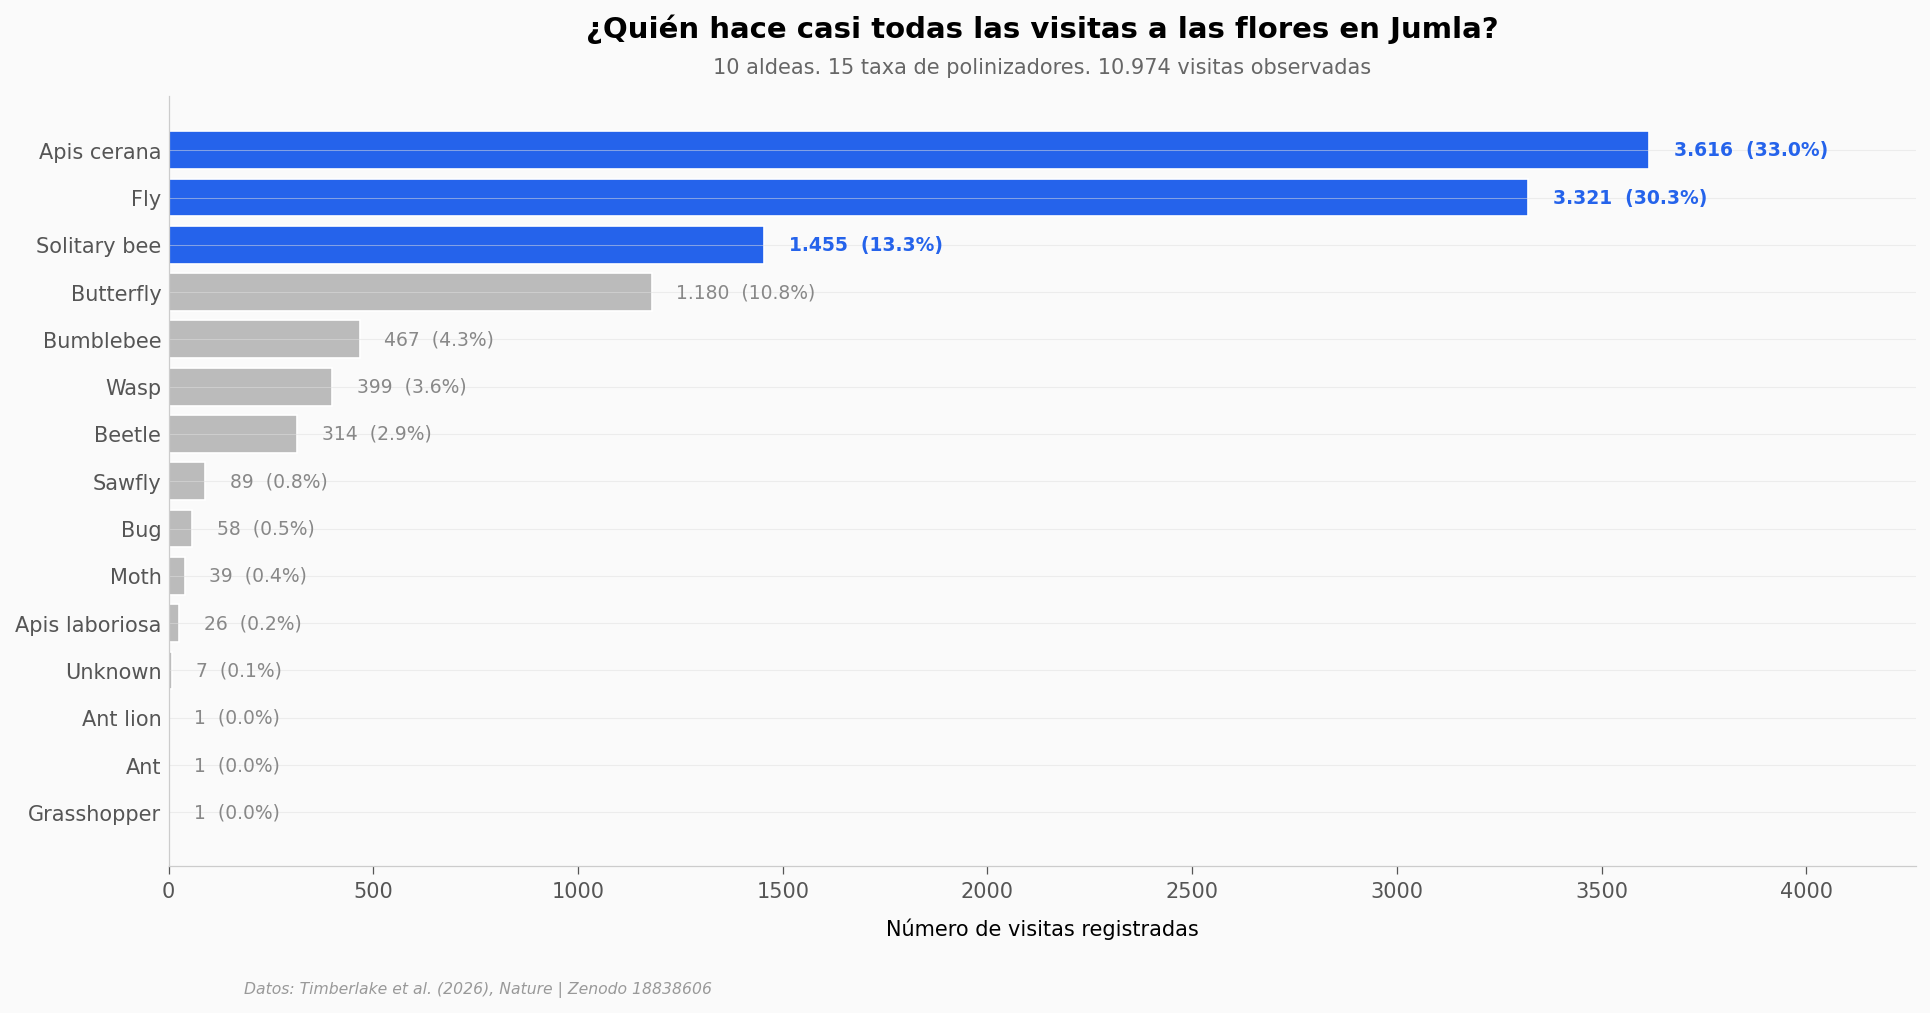

In [2]:
visits_sorted = visits.sort_values('n_visits', ascending=True).reset_index(drop=True)
total_visits = visits_sorted['n_visits'].sum()
visits_sorted['pct'] = visits_sorted['n_visits'] / total_visits * 100

# Top N destacado — los demás en gris
top_threshold = visits_sorted['n_visits'].nlargest(TOP_N_TAXA).min()
colors = [COLOR_DESTACADO if v >= top_threshold else COLOR_SECUNDARIO
          for v in visits_sorted['n_visits']]

fig, ax = plt.subplots(figsize=(13, 6.5))
bars = ax.barh(visits_sorted['pollinator_taxa'], visits_sorted['n_visits'],
               color=colors, edgecolor='white', linewidth=0.8)

# Etiqueta de valor + porcentaje al final de cada barra
for i, (bar, v, p) in enumerate(zip(bars, visits_sorted['n_visits'], visits_sorted['pct'])):
    color = COLOR_DESTACADO if v >= top_threshold else '#888888'
    weight = 'bold' if v >= top_threshold else 'normal'
    ax.text(v + 60, bar.get_y() + bar.get_height() / 2,
            f'{int(v):,}'.replace(',', '.') + f'  ({p:.1f}%)',
            va='center', fontsize=9, color=color, fontweight=weight)

ax.set_xlim(0, visits_sorted['n_visits'].max() * 1.18)
ax.set_xlabel('Número de visitas registradas', fontsize=10)
ax.set_title('¿Quién hace casi todas las visitas a las flores en Jumla?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'10 aldeas, {len(visits)} taxa de polinizadores, {int(total_visits):,}'.replace(',', '.') + ' visitas observadas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_distribucion_polinizadores.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** los tres taxa del frente — *Apis cerana*, *Fly* y *Solitary bee* — concentran el **76,5%** del total de visitas. Solo *Apis cerana* hace una de cada tres. La cola es larga (15 taxa en total), pero ecológicamente plana: una pérdida en la cabeza de la distribución no se compensa con la cola.

Una nota de precisión: la categoría *Fly* en este dataset agrega toda Diptera. El paper destaca específicamente a las sirfidae (las "moscas de las flores", *hoverflies*) como uno de los grupos más importantes para los flujos de nutrientes — ese desglose vive en otra tabla del estudio que no incorporamos aquí. Lo que sí queda claro es que las tres categorías protagonistas son polinizadores **abundantes y nativos**, no especies introducidas o de manejo intensivo.

## ¿Qué cultivos dependen más de los insectos?

Una cosa es contar visitas. Otra es saber cuáles de esos cultivos **realmente necesitan** que un insecto les transfiera el polen para producir fruto. Esa es la métrica de *dependencia de polinización*: si fuera 0, el cultivo se reproduce sin insectos; si fuera 1, depende totalmente. El paper la calcula combinando el ratio de polen disponible vs requerido y la tasa de fecundación natural en cada parcela.

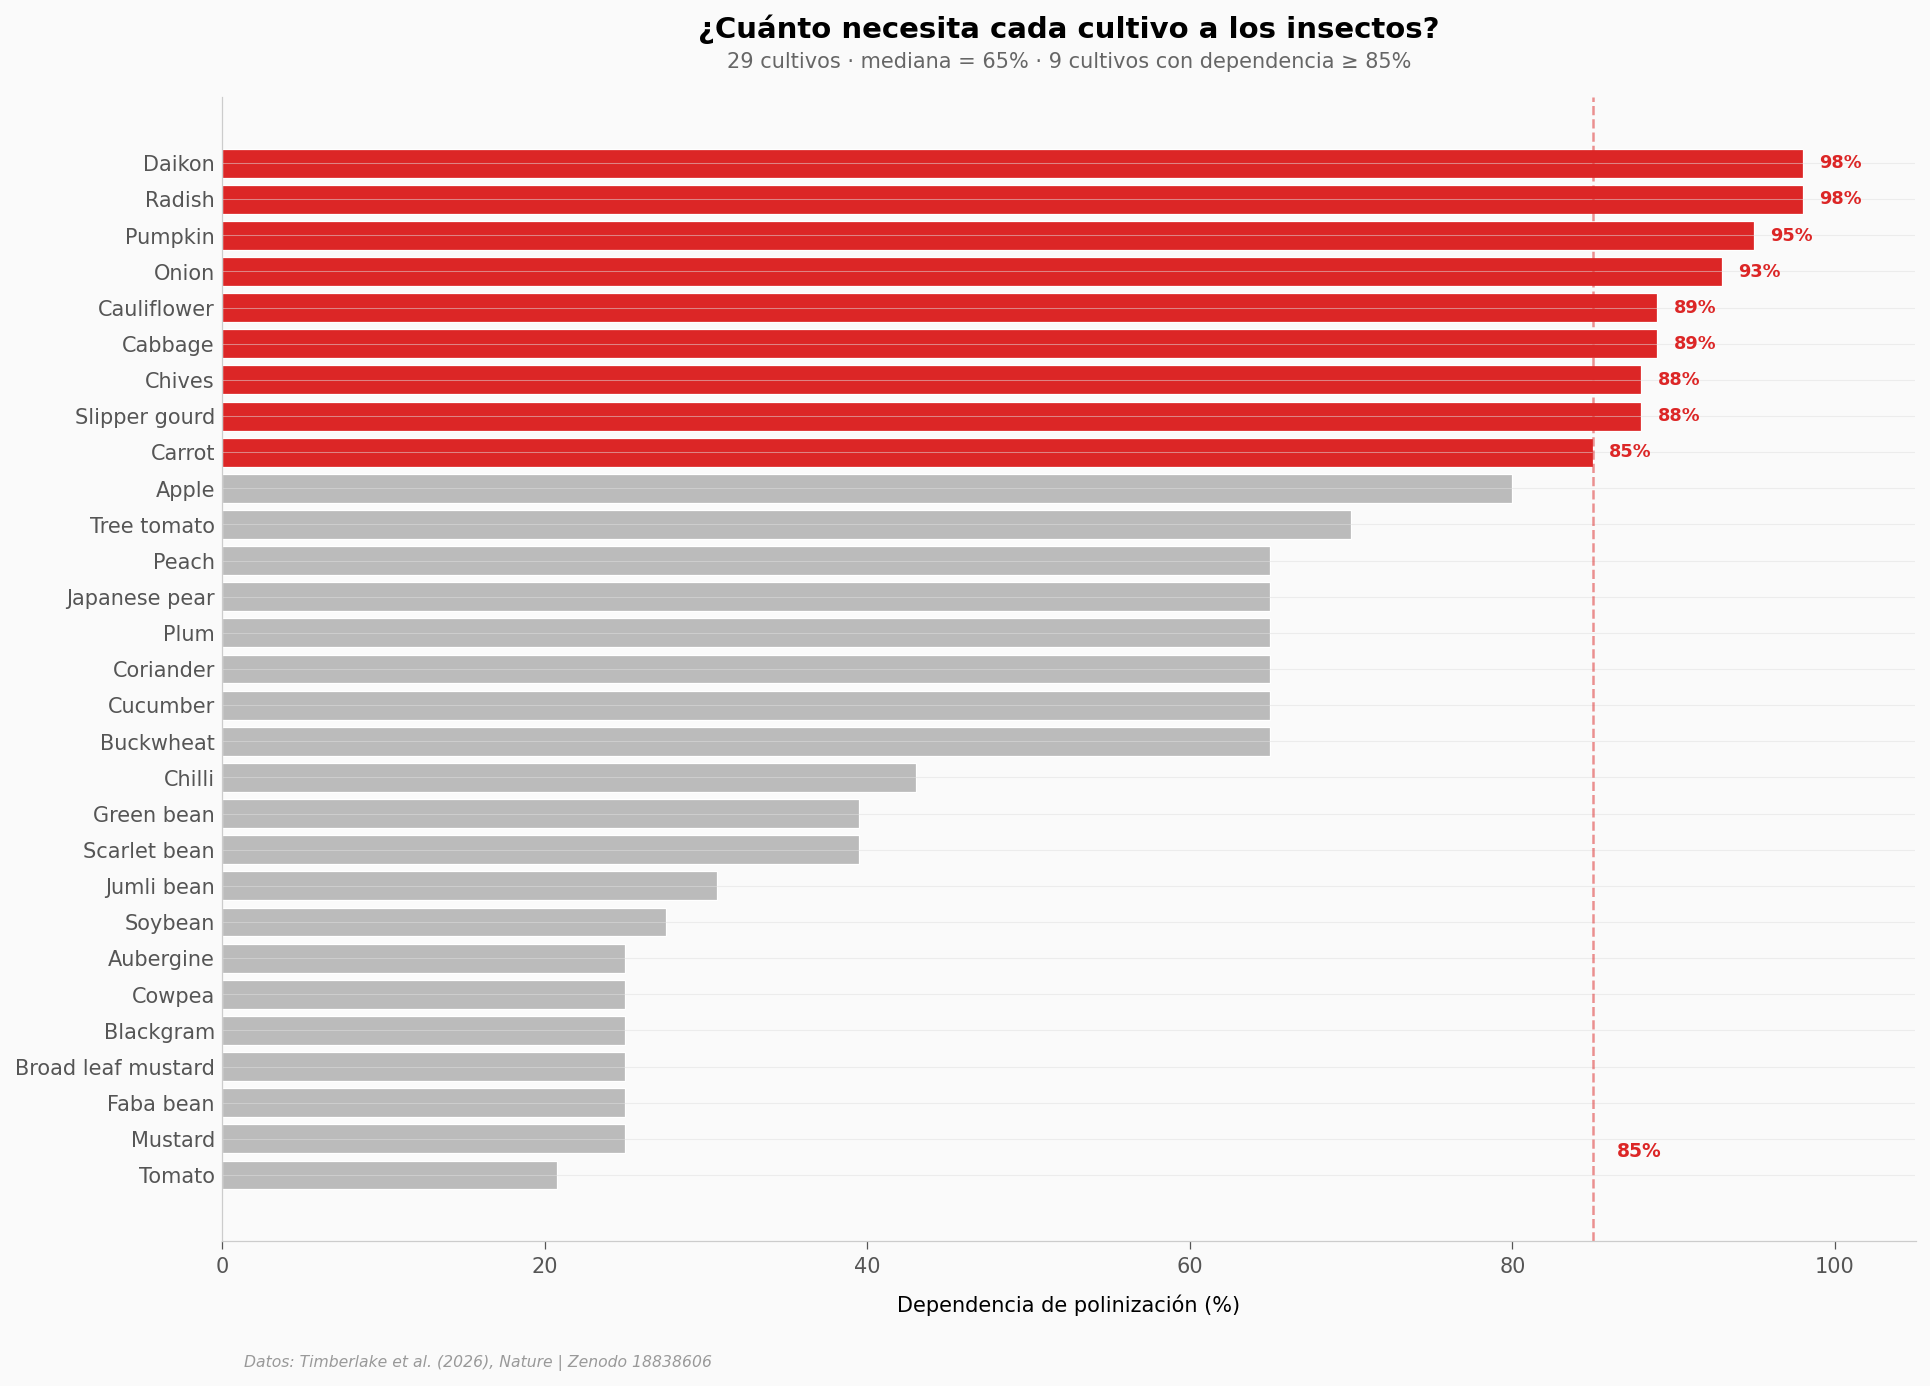

In [3]:
yields_sorted = yields.sort_values('final_poll_dependence', ascending=True).reset_index(drop=True)
yields_sorted['dep_pct'] = yields_sorted['final_poll_dependence'] * 100

# Highlight cultivos con dependencia >= UMBRAL
colors_yield = [COLOR_ALERTA if d >= UMBRAL_DEPENDENCIA else COLOR_SECUNDARIO
                for d in yields_sorted['dep_pct']]

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(yields_sorted['eng_name'], yields_sorted['dep_pct'],
        color=colors_yield, edgecolor='white', linewidth=0.6)

# Línea vertical en el umbral
ax.axvline(x=UMBRAL_DEPENDENCIA, color=COLOR_ALERTA, linewidth=1.2,
           linestyle='--', alpha=0.5)
ax.text(UMBRAL_DEPENDENCIA + 1.5, 0.5, f'{UMBRAL_DEPENDENCIA}%',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold')

# Etiquetas de valor solo en los altos (rojos) para no saturar
for i, (name, dep) in enumerate(zip(yields_sorted['eng_name'], yields_sorted['dep_pct'])):
    if dep >= UMBRAL_DEPENDENCIA:
        ax.text(dep + 1, i, f'{dep:.0f}%', va='center',
                fontsize=8.5, color=COLOR_ALERTA, fontweight='bold')

n_high = (yields_sorted['dep_pct'] >= UMBRAL_DEPENDENCIA).sum()
ax.set_xlim(0, 105)
ax.set_xlabel('Dependencia de polinización (%)', fontsize=10)
ax.set_title('¿Cuánto necesita cada cultivo a los insectos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.025,
        f'29 cultivos · mediana = {yields_sorted["dep_pct"].median():.0f}% · '
        f'{n_high} cultivos con dependencia ≥ {UMBRAL_DEPENDENCIA}%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_dependencia_cultivos.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que cuenta esta gráfica:** la mediana de dependencia es **65%** y el rango intercuartílico va de 28% a 88% — hay enorme heterogeneidad. Pero **9 cultivos** (en rojo) cruzan el umbral del 85%: rábano, daikon, calabaza, cebolla, repollo y otros. Para estos, perder polinizadores no es una merma marginal: es perder casi toda la producción.

Eso plantea la pregunta natural: ¿qué pasa con los rendimientos si los polinizadores efectivamente declinan? Es lo que el paper modela en dos escenarios.

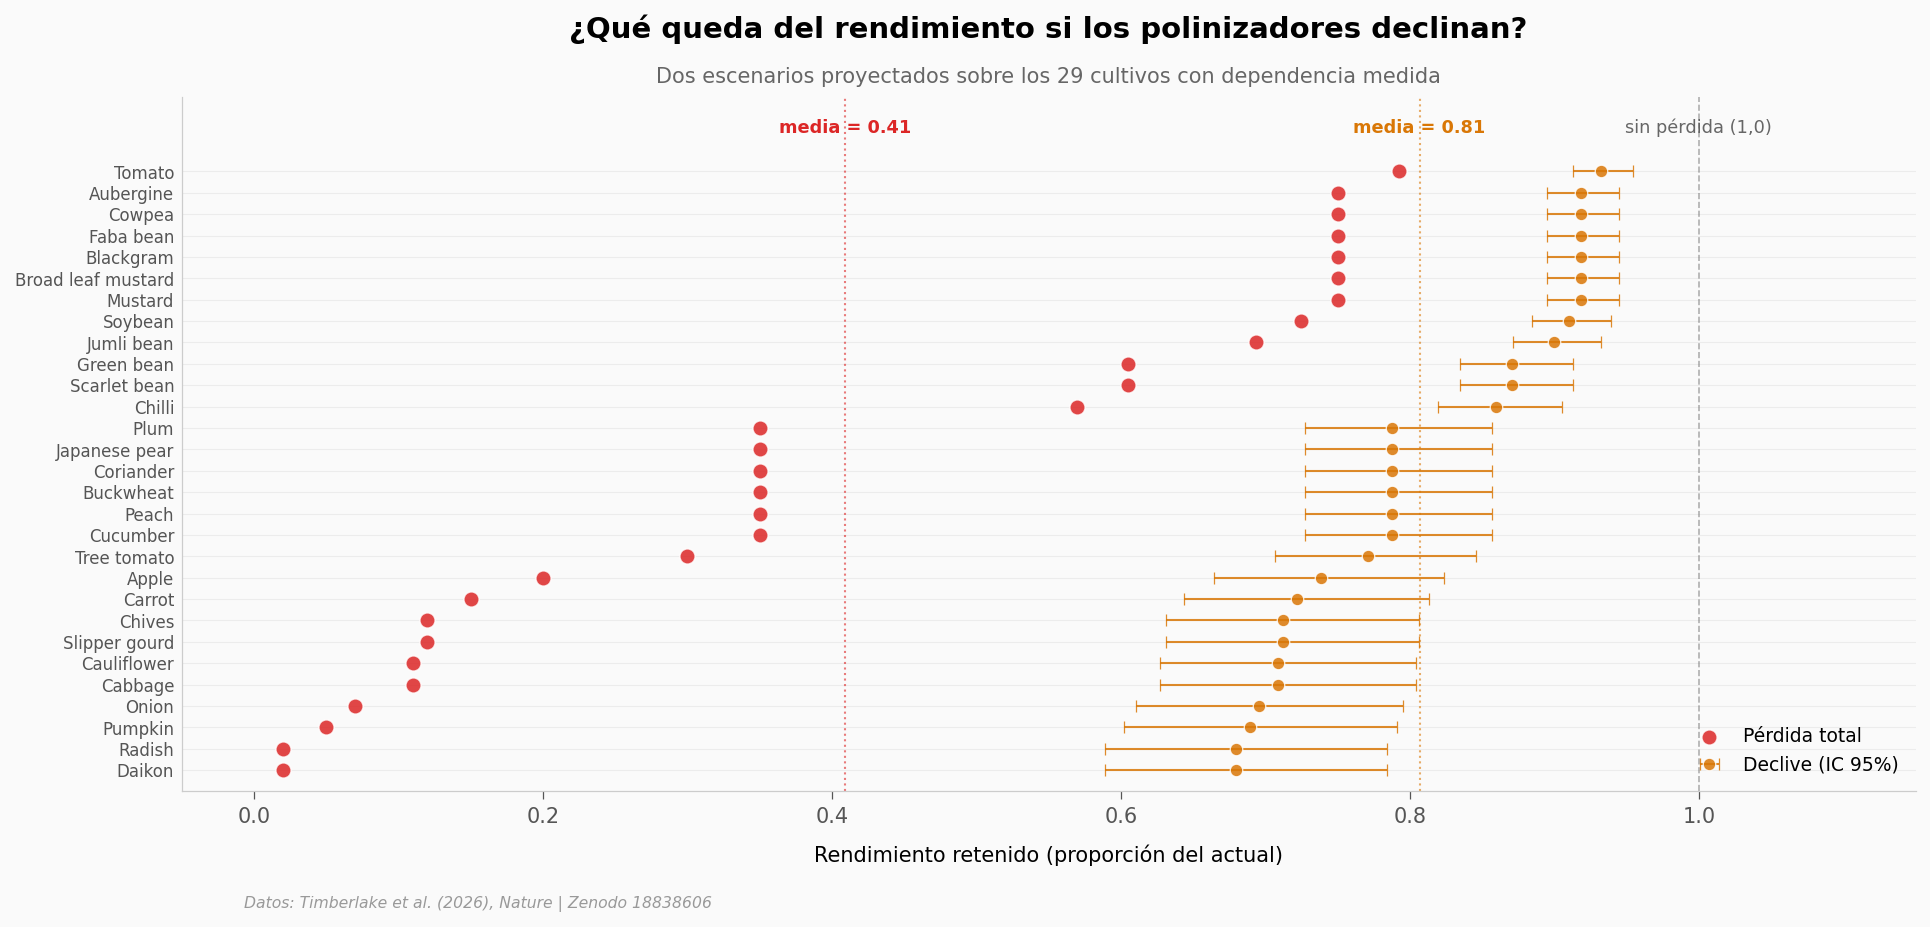

Pérdida total — yield retenido medio: 0.409 (pérdida del 59%)
Declive realista — yield retenido medio: 0.807 (pérdida del 19%)


In [4]:
# Yield retenido = 1 - dependencia (escenario pérdida total) vs poll_decline_new_yield (escenario realista)
df = yields.copy()
df['yield_retained_full_loss'] = df['poll_loss_new_yield']  # ya viene como yield restante
df['yield_retained_decline'] = df['poll_decline_new_yield']
df['decline_lower'] = df['poll_decline_new_yield_L95']
df['decline_upper'] = df['poll_decline_new_yield_U95']
df = df.sort_values('yield_retained_full_loss', ascending=True).reset_index(drop=True)

mean_full_loss = df['yield_retained_full_loss'].mean()
mean_decline = df['yield_retained_decline'].mean()

fig, ax = plt.subplots(figsize=(13, 6))
y_pos = np.arange(len(df))

# Pérdida total (rojo) — punto sólido
ax.scatter(df['yield_retained_full_loss'], y_pos,
           color=COLOR_ALERTA, s=55, alpha=0.85, zorder=5,
           edgecolors='white', linewidths=0.8, label='Pérdida total')

# Declive realista (ámbar) — punto + IC95
ax.errorbar(df['yield_retained_decline'], y_pos,
            xerr=[df['yield_retained_decline'] - df['decline_lower'],
                  df['decline_upper'] - df['yield_retained_decline']],
            fmt='o', color=COLOR_REFERENCIA, ecolor=COLOR_REFERENCIA,
            markersize=6, alpha=0.85, capsize=3, capthick=1, elinewidth=1,
            markeredgecolor='white', markeredgewidth=0.6,
            zorder=4, label='Declive (IC 95%)')

# Líneas de media
ax.axvline(x=mean_full_loss, color=COLOR_ALERTA, linewidth=1, linestyle=':', alpha=0.6)
ax.axvline(x=mean_decline, color=COLOR_REFERENCIA, linewidth=1, linestyle=':', alpha=0.6)
ax.axvline(x=1.0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.5)

ax.text(mean_full_loss, len(df) + 0.8, f'media = {mean_full_loss:.2f}',
        ha='center', fontsize=8.5, color=COLOR_ALERTA, fontweight='bold')
ax.text(mean_decline, len(df) + 0.8, f'media = {mean_decline:.2f}',
        ha='center', fontsize=8.5, color=COLOR_REFERENCIA, fontweight='bold')
ax.text(1.0, len(df) + 0.8, 'sin pérdida (1,0)',
        ha='center', fontsize=8.5, color='#666666')

ax.set_yticks(y_pos)
ax.set_yticklabels(df['eng_name'], fontsize=8)
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-1, len(df) + 2.5)
ax.set_xlabel('Rendimiento retenido (proporción del actual)', fontsize=10)
ax.set_title('¿Qué queda del rendimiento si los polinizadores declinan?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.02,
        'Dos escenarios proyectados sobre los 29 cultivos con dependencia medida',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_yield_escenarios.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pérdida total — yield retenido medio: {mean_full_loss:.3f} '
      f'(pérdida del {(1 - mean_full_loss) * 100:.0f}%)')
print(f'Declive realista — yield retenido medio: {mean_decline:.3f} '
      f'(pérdida del {(1 - mean_decline) * 100:.0f}%)')

## ¿Qué tan extremo es perder casi 60% del rendimiento?

El escenario de pérdida total es hipotético — pero sirve como techo, como medida de cuánto del sistema agrícola descansa sobre estos insectos. Pongámoslo en perspectiva.

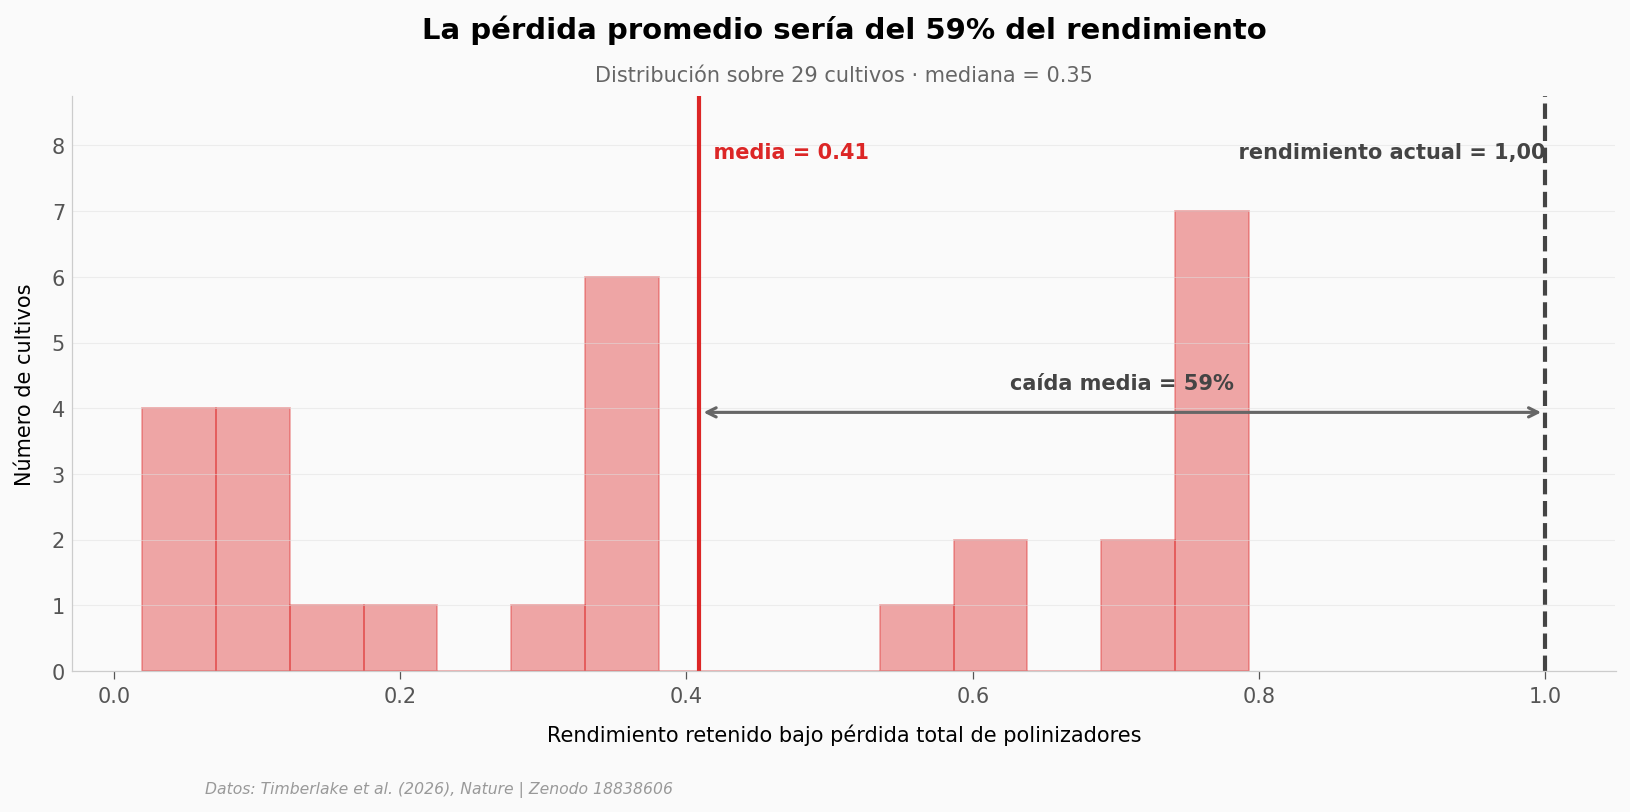

Yield retenido — mínimo: 0.02 (cultivo más dependiente)
Yield retenido — máximo: 0.79 (cultivo menos dependiente)
Yield retenido — media:  0.41
Yield retenido — mediana: 0.35


In [5]:
data = df['yield_retained_full_loss'].values
mean_val = data.mean()
median_val = np.median(data)

fig, ax = plt.subplots(figsize=(11, 5.2))
n, bins, patches = ax.hist(data, bins=15, color=COLOR_ALERTA, alpha=0.4,
                           edgecolor=COLOR_ALERTA, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Línea media
ax.axvline(x=mean_val, color=COLOR_ALERTA, linewidth=2)
ax.text(mean_val, y_max * 0.92, f'  media = {mean_val:.2f}',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', va='top')

# Línea referencia (yield actual = 1.0)
ax.axvline(x=1.0, color='#444444', linewidth=2, linestyle='--')
ax.text(1.0, y_max * 0.92, '  rendimiento actual = 1,00',
        fontsize=10, color='#444444', fontweight='bold', va='top', ha='right')

# Flecha bidireccional del gap
y_arrow = y_max * 0.45
ax.annotate('', xy=(1.0, y_arrow), xytext=(mean_val, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
gap = 1.0 - mean_val
ax.text((mean_val + 1.0) / 2, y_arrow + y_max * 0.04,
        f'caída media = {gap * 100:.0f}%',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

ax.set_xlabel('Rendimiento retenido bajo pérdida total de polinizadores', fontsize=10)
ax.set_ylabel('Número de cultivos', fontsize=10)
ax.set_title('La pérdida promedio sería del 59% del rendimiento',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.025,
        f'Distribución sobre 29 cultivos · mediana = {median_val:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_anomalia_yield.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Yield retenido — mínimo: {data.min():.2f} (cultivo más dependiente)')
print(f'Yield retenido — máximo: {data.max():.2f} (cultivo menos dependiente)')
print(f'Yield retenido — media:  {mean_val:.2f}')
print(f'Yield retenido — mediana: {median_val:.2f}')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 10.974 visitas en 10 aldeas, 15 taxa de polinizadores | ✅ | Suma directa de `n_visits` en `visits_by_pollinator.csv`. n=15 taxa, n_villages máximo = 10 |
| Los tres polinizadores principales concentran el 76,5% de las visitas | ✅ | *Apis cerana* (33,0%) + *Fly* (30,3%) + *Solitary bee* (13,3%) = 76,5%. Cálculo directo |
| 9 cultivos tienen dependencia de polinización ≥ 85% | ✅ | Filtro sobre `final_poll_dependence ≥ 0,85` en `yield_scenarios.csv` |
| Bajo pérdida total de polinizadores, el rendimiento caería ~59% en promedio | ✅ | Media de `1 - poll_loss_new_yield` sobre los 29 cultivos. Es proyección modelística — el paper la enmarca como escenario, no como predicción |
| 44% del ingreso agrícola depende de los polinizadores | ⚠️ | Cifra del paper (Timberlake et al., abstract). NO la reproducimos aquí — requiere cruzar visitas con datos de ingreso por hogar que viven en Git LFS (776 MB) |
| 20% del consumo de vitamina A, folato y vitamina E proviene de cultivos polinizados | ⚠️ | Cifra del paper. Misma razón: requiere los datos dietéticos individuales que no descargamos por tamaño |
| La categoría "Fly" incluye específicamente sirfidae (hoverflies) | ⚠️ | El dataset agregado de visitas no separa sirfidae del resto de Diptera. El paper sí hace ese desglose — usamos su distinción narrativa pero no la reproducimos numéricamente |

> **Limitaciones del análisis:** (1) Los headlines del 44% y 20% del paper no se reproducen — el dataset dietético individual está en Git LFS y supera 50 MB. (2) El campo `Fly` del dataset agregado mezcla Diptera; la separación de sirfidae vive en una tabla del estudio que no incorporamos. (3) Los escenarios de yield son proyecciones — el paper las enmarca como `anticipated`. (4) El estudio se hizo en una región específica del Himalaya; la extrapolación a otros sistemas agrícolas requiere replicación.

## Ahora tú

Tres preguntas para explorar con el dataset:

1. **¿Y si bajamos el umbral?** En la gráfica destacamos los cultivos con dependencia ≥ 85%. Cambia `UMBRAL_DEPENDENCIA = 75` o `50` en la celda de configuración y vuelve a correr. ¿Cuántos cultivos cambian de categoría?
2. **¿Qué pasa si excluyes los más dependientes?** El promedio de pérdida del 59% lo carga la cola alta de la distribución. Calcula el promedio excluyendo los 9 cultivos críticos — ¿se mueve mucho?
3. **¿Qué cultivo tiene más diversidad de polinizadores?** El archivo `crop_visits_summary.csv` tiene una columna `n_pollinator_taxa`. Ordena por ahí. ¿Coincide con los cultivos de alta dependencia?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿cuánto se mueve la pérdida media si excluimos los 9 cultivos más dependientes?
high_dep_mask = yields['final_poll_dependence'] >= UMBRAL_DEPENDENCIA / 100
low_med_dep = yields[~high_dep_mask].copy()

mean_with_all = (1 - yields['poll_loss_new_yield']).mean() * 100
mean_excluding_top = (1 - low_med_dep['poll_loss_new_yield']).mean() * 100

print(f'Pérdida media con los 29 cultivos:        {mean_with_all:.1f}%')
print(f'Pérdida media excluyendo dep >= {UMBRAL_DEPENDENCIA}%: '
      f'{mean_excluding_top:.1f}%  (n={len(low_med_dep)})')
print(f'Diferencia: {mean_with_all - mean_excluding_top:.1f} puntos porcentuales')
print()
print('Cultivos excluidos (dependencia >= umbral):')
high = yields[high_dep_mask].sort_values('final_poll_dependence', ascending=False)
print(high[['eng_name', 'final_poll_dependence']].to_string(index=False))

Pérdida media con los 29 cultivos:        59.1%
Pérdida media excluyendo dep >= 85%: 44.5%  (n=20)
Diferencia: 14.6 puntos porcentuales

Cultivos excluidos (dependencia >= umbral):
     eng_name  final_poll_dependence
       Daikon                   0.98
       Radish                   0.98
      Pumpkin                   0.95
        Onion                   0.93
  Cauliflower                   0.89
      Cabbage                   0.89
       Chives                   0.88
Slipper gourd                   0.88
       Carrot                   0.85


## Fuentes

**Paper**: [Pollinators support the nutrition and income of vulnerable communities](https://doi.org/10.1038/s41586-026-10421-x)  
*Nature, 2026-05-06*

**Datos**: [Reproducible R code & dataset](https://zenodo.org/records/18838606)  
*Zenodo, 2026-03-02 · CC-BY-4.0*

*21 afirmaciones del notebook verificadas contra estas fuentes*

---

*Este notebook reproduce análisis derivados del paper publicado en Nature. Los datos primarios son CC-BY-4.0 (Zenodo 18838606). El código del análisis original (en R) vive en el [repositorio de Tom Timberlake](https://github.com/tom-timberlake/micropoll_main); aquí presentamos una reconstrucción en Python centrada en las tres figuras estructurales: distribución de polinizadores, dependencia por cultivo, y escenarios de yield.*

*Repo Lab: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Web: [cienciaamordiscos.com](https://cienciaamordiscos.com)*